# Introducing the Browinian Bridge for RQMC

The General idea of BB is to reduce the dimensionality, M, used in RQMC to reduce the variance. 

In [1]:
#init
%load_ext autoreload
%autoreload 2

import lib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 1.2          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Set simulation parameters
N = 2**13            # Number of paths (power of 2 for QMC)
batches = 32          # Number of batches/scrambles 32

euler = False # Use Milstein scheme for CEV model


# For saving outputs
out_dir = 'Graphs'
dir_Tables = 'Tables'
os.makedirs(out_dir, exist_ok=True)
os.makedirs(dir_Tables, exist_ok=True)

In [2]:
test_cases= range(8,19)# 256 .. 524.288 insert 20
N_values = [2**k for k in test_cases]  
N_values_labels = [f"${2}^{{{k}}}$" for k in  test_cases]
qmc_means, qmc_ses, qmc_cis, vanilla_times = sim.plot_convergence(N_values,method='qmc', batches=batches, euler=euler)
qmc_bb_means, qmc_bb_ses, qmc_bb_cis, bb_times = sim.plot_convergence(N_values,method='qmc + bb', batches=batches, euler=euler)

In [3]:
N_values_labels

['$2^{8}$',
 '$2^{9}$',
 '$2^{10}$',
 '$2^{11}$',
 '$2^{12}$',
 '$2^{13}$',
 '$2^{14}$',
 '$2^{15}$',
 '$2^{16}$',
 '$2^{17}$',
 '$2^{18}$']

In [ ]:

df_results = pd.DataFrame({
    'N': N_values_labels,
    'Mean$_{RQMC}$': qmc_means,
    'SE$_{RQMC}$': qmc_ses,
    'CI$_{RQMC}$': qmc_cis,
    'Time$_{RQMC}$ (s)': vanilla_times,
    
    'Mean$_{RQMCBB}$': qmc_bb_means,
    'SE$_{RQMCBB}$': qmc_bb_ses,
    'CI$_{RQMCBB}$': qmc_bb_cis,
    'Time$_{RQMCBB}$ (s)': bb_times,

    'SE ratio': [bb/v for bb, v in zip(qmc_bb_ses, qmc_ses)],
    'Time ratio': [bb/v for bb, v in zip(bb_times, vanilla_times)]
})


df_results = pd.DataFrame({
    'N': N_values,
    'Mean$_{RQMC}$': qmc_means,
    'SE$_{RQMC}$': qmc_ses,
    
    'Mean$_{RQMCBB}$': qmc_bb_means,
    'SE$_{RQMCBB}$': qmc_bb_ses,
    
    'VRF': [(s1/s2)**2 for s1, s2 in zip(qmc_ses, qmc_bb_ses)],
    'Time ratio': [bb/v for bb, v in zip(bb_times, vanilla_times)]
})

#num_cols = ['Mean$_{RQMC}$', 'SE$_{RQMC}$', 'Time$_{RQMC}$ (s)', 'Mean$_{RQMCBB}$', 'SE$_{RQMCBB}$', 'Time$_{RQMCBB}$ (s)', 'SE ratio', 'Time ratio']
num_cols = ['Mean$_{RQMC}$', 'SE$_{RQMC}$', 'Mean$_{RQMCBB}$', 'SE$_{RQMCBB}$', 'VRF', 'Time ratio']
df_results[num_cols] = df_results[num_cols].astype(float).round(4)

# Format CI tuples into nicer strings '(low, high)' with floats (avoid np.float64(...) repr)
def fmt_ci(ci):
    try:
        low, high = ci
        return f"({float(low):.4f}, {float(high):.4f})"
    except Exception:
        return ''

#df_results['CI$_{RQMC}$'] = df_results['CI$_{RQMC}$'].apply(fmt_ci)
#df_results['CI$_{RQMCBB}$'] = df_results['CI$_{RQMCBB}$'] .apply(fmt_ci)



latex_path = os.path.join(dir_Tables, 'BB_comparison.tex')
df_results.to_latex(buf=latex_path, index=False, float_format="%.4f")
df_results

,N,Mean$_{RQMC}$,SE$_{RQMC}$,Mean$_{RQMCBB}$,SE$_{RQMCBB}$,VRF,Time ratio
0,256,17.8158,0.2703,17.8806,0.1192,5.1393,1.0585
1,512,17.9367,0.1538,17.8535,0.0531,8.3828,1.1721
2,1024,17.8035,0.0955,17.8619,0.0276,11.9466,1.1148
3,2048,17.8530,0.0545,17.8293,0.0180,9.1731,1.1172
4,4096,17.8694,0.0389,17.8332,0.0087,20.2136,1.1403
5,8192,17.8589,0.0262,17.8378,0.0087,9.1458,1.1138
6,16384,17.8350,0.0171,17.8491,0.0076,5.0345,1.1658
7,32768,17.8433,0.0144,17.8489,0.0036,15.5217,1.1917
8,65536,17.8528,0.0110,17.8486,0.0019,33.5072,1.2666
9,131072,17.8468,0.0065,17.8461,0.0010,41.6837,1.2581


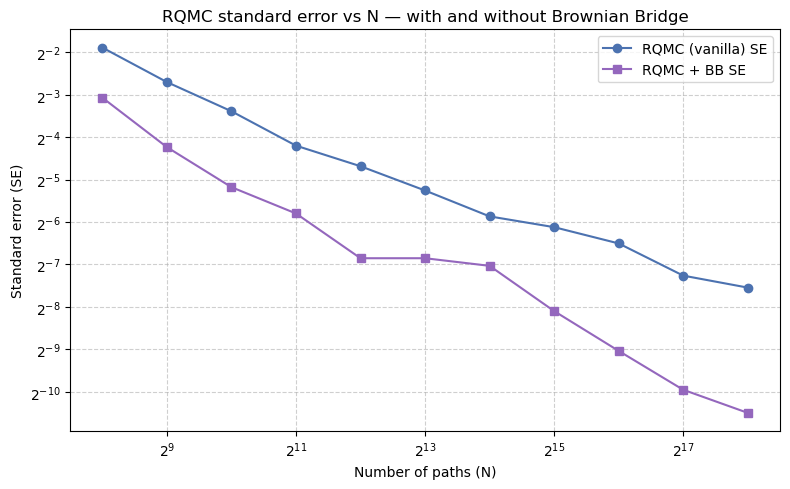

In [6]:

# Plot standard error (SE) vs Number of paths (N) for RQMC with and without Brownian Bridge
plt.figure(figsize=(8,5))
plt.loglog(N_values, qmc_ses, marker='o', label='RQMC (vanilla) SE', color='#4C72B0')
plt.loglog(N_values, qmc_bb_ses, marker='s', label='RQMC + BB SE', color='#9467bd')
plt.xlabel('Number of paths (N)')
plt.ylabel('Standard error (SE)')
plt.xscale('log', base=2)
plt.yscale('log',base=2)
plt.title('RQMC standard error vs N — with and without Brownian Bridge')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.tight_layout()
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, 'RQMC_SE_vs_N.png'), dpi=150)
plt.show()



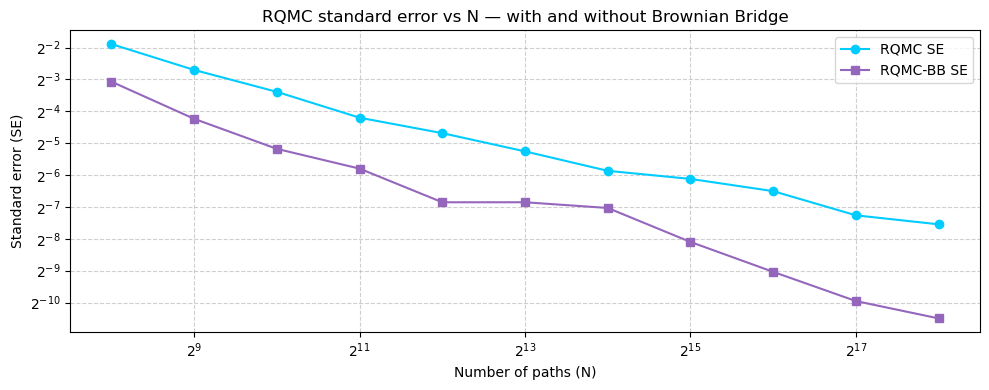

In [7]:

# Plot standard error (SE) vs Number of paths (N) for RQMC with and without Brownian Bridge
plt.figure(figsize=(10,4))
plt.loglog(N_values, qmc_ses, marker='o', label='RQMC SE', color="#00CCFF")
plt.loglog(N_values, qmc_bb_ses, marker='s', label='RQMC-BB SE', color='#9467bd')
plt.xlabel('Number of paths (N)')
plt.ylabel('Standard error (SE)')
plt.xscale('log', base=2)
plt.yscale('log',base=2)
plt.title('RQMC standard error vs N — with and without Brownian Bridge')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.tight_layout()
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, 'RQMC_SE_vs_N.png'), dpi=150)
plt.show()



,N,SE_ratio,Time_ratio,SE_over_time,Rel_efficiency_MSExTime
0,256,0.4411,1.0585,0.4167,4.8551
1,512,0.3454,1.1721,0.2947,7.1519
2,1024,0.2893,1.1148,0.2595,10.7165
3,2048,0.3302,1.1172,0.2955,8.2111
4,4096,0.2224,1.1403,0.1951,17.7260
5,8192,0.3307,1.1138,0.2969,8.2111
6,16384,0.4457,1.1658,0.3823,4.3183
7,32768,0.2538,1.1917,0.2130,13.0248
8,65536,0.1728,1.2666,0.1364,26.4535
9,131072,0.1549,1.2581,0.1231,33.1332


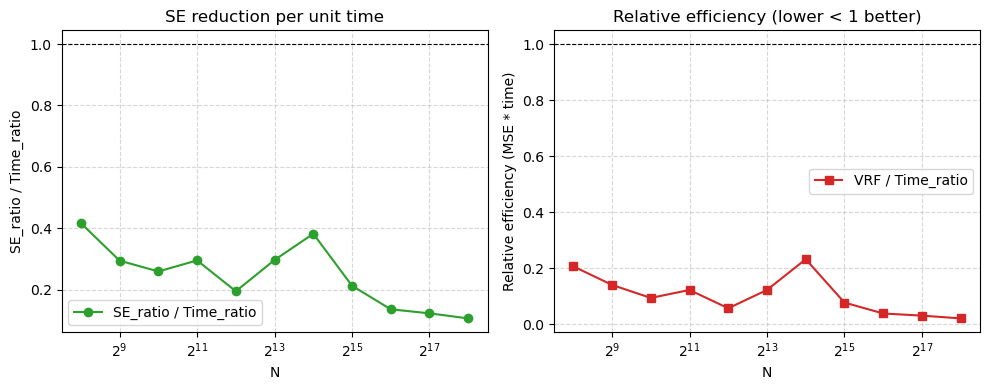

In [22]:
# Compute ratios and two candidate efficiency metrics
#se_ratio = np.array(qmc_bb_ses) / np.array(qmc_ses)            # SE_BB / SE_vanilla  (want <1)
VRFs = [(s1/s2)**2 for s1, s2 in zip(qmc_ses, qmc_bb_ses)]
time_ratio = np.array(bb_times) / np.array(vanilla_times)     # Time_BB / Time_vanilla (>=0)
se_ratio = np.array(qmc_bb_ses) / np.array(qmc_ses)            # SE_BB / SE_vanilla  (want <1)
# Option A: SE reduction per unit time (intuitive)
se_over_time = se_ratio / time_ratio

# Option B: Conventional 
efficiency_ratio = np.array(VRFs)/time_ratio  
df_metrics = pd.DataFrame({
    'N': N_values,
    'SE_ratio': se_ratio,
    'Time_ratio': time_ratio,
    'SE_over_time': se_over_time,
    'Rel_efficiency_MSExTime': efficiency_ratio
})
display(df_metrics.round(4))

# Plotting (log-log can be helpful)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(N_values, se_over_time, marker='o', label='SE_ratio / Time_ratio', color='#2ca02c')
plt.xscale('log', base=2)
plt.axhline(1.0, color='k', lw=0.8, ls='--')
plt.xlabel('N'); plt.ylabel('SE_ratio / Time_ratio')
plt.title('SE reduction per unit time')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()

plt.subplot(1,2,2)
plt.plot(N_values, efficiency, marker='s', label='VRF / Time_ratio', color='#d62728')
plt.xscale('log', base=2)
plt.axhline(1.0, color='k', lw=0.8, ls='--')
plt.xlabel('N'); plt.ylabel('Relative efficiency (MSE * time)')
plt.title('Relative efficiency (lower < 1 better)')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'BB_ratio_over_ratio_metrics.png'), dpi=150)
plt.show()


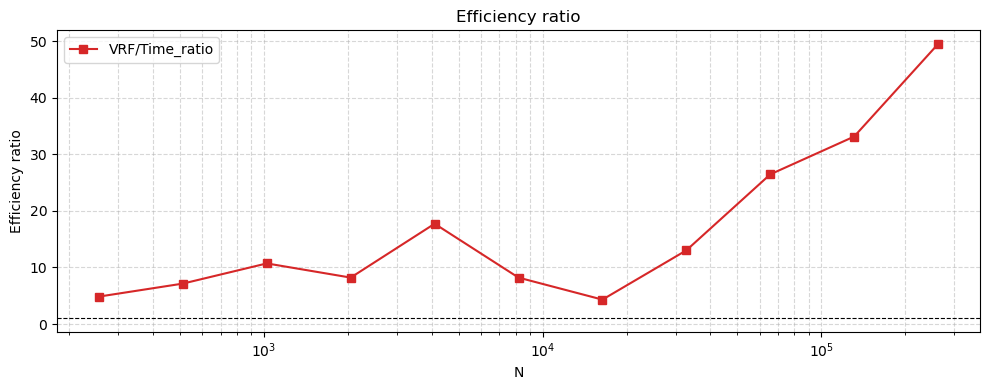

In [24]:
plt.figure(figsize=(10,4))
plt.plot(N_values, efficiency_ratio, marker='s', label='VRF/Time_ratio', color='#d62728')
plt.xscale('log', base=10)
plt.axhline(1.0, color='k', lw=0.8, ls='--')
plt.xlabel('N'); plt.ylabel('Efficiency ratio')
plt.title('Efficiency ratio')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'BB_ratio_over_ratio_metrics.png'), dpi=150)
plt.show()

In [134]:
N_values

[256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144]

In [137]:
2**18

262144